# Analisis Exploratorio Detallado: Video Games Sales (1980-2024)

Este notebook documenta un EDA (Exploratory Data Analysis) profundo para entender el dataset de ventas de videojuegos.

El objetivo es que cualquier persona, incluso sin contexto previo, pueda leer este documento y entender:
- que representa cada variable,
- si es cuantitativa o cualitativa,
- que problemas de calidad de datos existen,
- que columnas requieren formateo o limpieza,
- que variables aportan (o no) informacion para analisis posteriores.

## 1. COMPRENSIÓN DEL PROBLEMA

### Problema que se resuelve
Este trabajo aborda un problema **descriptivo-diagnostico**: entender como se comporta el mercado de videojuegos por plataforma, genero, region y periodo temporal, usando un dataset historico de ventas y score critico.

### Usuario final
El analisis esta orientado a un **analista de marketing y portafolio** en una publicadora/distribuidora de videojuegos.

### Decisiones que este analisis puede habilitar
1. Priorizar plataformas y generos para nuevos lanzamientos.
2. Ajustar presupuesto de marketing por region (NA, JP, PAL, Other).
3. Detectar periodos de alta saturacion y oportunidades de nicho.
4. Definir combinaciones de variables para un futuro modelo predictivo de ventas.

### Variable de negocio mas sensible
La variable mas critica para toma de decisiones es `total_sales` (junto a su desglose regional), porque representa resultado comercial directo.

### Riesgos de mala interpretacion
- Confundir **correlacion** con causalidad (por ejemplo, score alto no implica por si solo ventas altas).
- Ignorar sesgos de cobertura del dataset (periodos o plataformas sobrerrepresentadas).
- No tratar inconsistencias entre ventas regionales y venta total.

### Criterio metodologico de este notebook
- Se justifican explicitamente decisiones de limpieza.
- Se compara enfoque con y sin imputacion para `critic_score`.
- Se adopta una regla hibrida para consistencia de ventas, documentada y trazable.

## 1.1 Objetivos y Alcance del EDA

### Objetivos del EDA
1. Auditar estructura y calidad del dataset.
2. Clasificar variables (cuantitativas/cualitativas, continuas/discretas, nominales/temporales).
3. Detectar valores faltantes, formatos incorrectos, incoherencias y potenciales duplicados.
4. Evaluar utilidad analitica de cada columna para modelado, dashboards o reportes.
5. Proponer una ruta de limpieza priorizada.

### Antes de empezar a codificar

En el siguiente bloque se configura el entorno de trabajo (librerias, opciones de visualizacion y formato de salida).

Por que se hace:
- Garantiza que todas las tablas y graficos se muestren de forma consistente.
- Mejora la legibilidad del analisis para terceros.
- Evita diferencias de formato entre ejecuciones.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Resultado de la configuracion
El entorno queda listo para ejecutar el EDA de forma reproducible:
- Librerias cargadas correctamente.
- Estilo grafico uniforme.
- Formato de salida numerica consistente.

Interpretacion: a partir de aqui, los resultados del notebook son comparables entre ejecuciones y mas faciles de comunicar.

## 2. COMPRENSIÓN DE LOS DATOS### 2.1 Carga de Datos y Vista Inicial

In [2]:
# Carga del dataset
csv_path = Path('Video Games Sales (1980-2024) - Raw.csv')
df = pd.read_csv(csv_path)

print(f'Ruta: {csv_path.resolve()}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head(5)

Ruta: /home/julian-celis/Documents/universidad/octavo_semestre/mineria/videoGames/Video Games Sales (1980-2024) - Raw.csv
Filas: 64,016 | Columnas: 14


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
# Estructura general y tipos iniciales
display(df.info())
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
img,64016,56177,/games/boxart/default.jpg,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,6678.0,NaN,NaN,NaN,7.22044,1.457066,1.0,6.4,7.5,8.3,10.0
total_sales,18922.0,NaN,NaN,NaN,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,NaN,NaN,NaN,0.26474,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,NaN,NaN,NaN,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13


In [4]:
# Crear copia de trabajo para transformaciones y análisis
df_work = df.copy()

print(f"✓ Datafame de trabajo creado")
print(f"  • Registros: {len(df_work):,}")
print(f"  • El original 'df' se mantiene intacto para trazabilidad")

✓ Datafame de trabajo creado
  • Registros: 64,016
  • El original 'df' se mantiene intacto para trazabilidad


In [5]:
# Derivar variables temporales desde release_date
df_work['release_date_parsed'] = pd.to_datetime(df_work['release_date'], errors='coerce', dayfirst=True)
df_work['release_year'] = df_work['release_date_parsed'].dt.year
df_work['release_month'] = df_work['release_date_parsed'].dt.month
df_work['release_decade'] = (df_work['release_year'] // 10 * 10).astype('Int64')

print(f"✓ Variables temporales derivadas:")
print(f"  • release_year: {df_work['release_year'].notna().sum():,} valores válidos")
print(f"  • release_month: {df_work['release_month'].notna().sum():,} valores válidos") 
print(f"  • release_decade: {df_work['release_decade'].notna().sum():,} valores válidos")

✓ Variables temporales derivadas:
  • release_year: 56,965 valores válidos
  • release_month: 56,965 valores válidos
  • release_decade: 56,965 valores válidos


### Resultado e interpretacion

- El dataset contiene 64016 filas y 14 columnas.
- Se observa una mezcla de variables categoricas, numericas y temporales.
- La primera auditoria muestra faltantes muy altos en variables de ventas y puntuacion critica.

Interpretacion: el dataset es util para EDA y analisis de negocio, pero no esta listo para modelado directo sin una estrategia formal de tratamiento de nulos y consistencia.

In [6]:
# Perfilado de tipos, cardinalidad y nulos por columna
summary = pd.DataFrame({
    'dtype_inicial': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(dropna=True)
}).sort_values(['pct_nulos', 'unicos'], ascending=[False, False])
summary

,dtype_inicial,nulos,pct_nulos,unicos
critic_score,float64,57338,89.57,89
jp_sales,float64,57290,89.49,121
na_sales,float64,51379,80.26,320
pal_sales,float64,51192,79.97,256
other_sales,float64,48888,76.37,133
last_update,str,46137,72.07,1545
total_sales,float64,45094,70.44,482
release_date,str,7051,11.01,7922
developer,str,17,0.03,8862
img,str,0,0.00,56177


## 2.2 Diccionario de Variables y Tipificación Analítica

### Que se va a hacer
Se clasificara cada variable desde una mirada analitica (no solo por el dtype tecnico): cuantitativa/cualitativa, temporal/nominal y nivel de cardinalidad.

### Por que se hace
El tipo analitico determina que tecnicas aplicar: estadistica descriptiva, visualizaciones, imputacion, codificacion, agregaciones o transformaciones. Esta tipificacion evita errores comunes como tratar categorias como numericas o viceversa.

En esta seccion clasificamos cada variable de forma analitica (no solo por dtype de pandas).

### Resultado e interpretacion

La clasificacion analitica deja claro que:
- El nucleo cuantitativo es `critic_score` y el bloque de ventas.
- El nucleo categorico es `title`, `console`, `genre`, `publisher`, `developer`.
- `release_date` y `last_update` son temporales y requieren parseo.

Interpretacion: esta separacion facilita elegir tecnicas correctas por tipo de variable y reduce riesgo de analisis metodologicamente incorrecto.


## 2.3 Auditoría de Calidad: Nulos y Duplicados

In [7]:
# Nulos por columna
null_table = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
null_table

,nulos,pct_nulos
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
developer,17,0.03
publisher,0,0.00


Porcentaje de nulos de critic_score por año (muestra):


,release_year,pct_nulos_critic_score
31,2005.0,79.337017
32,2006.0,75.954198
33,2007.0,82.970297
34,2008.0,82.629428
35,2009.0,82.431193
36,2010.0,81.204685
37,2011.0,76.698169
38,2012.0,92.108586
39,2013.0,92.298851
40,2014.0,97.030387


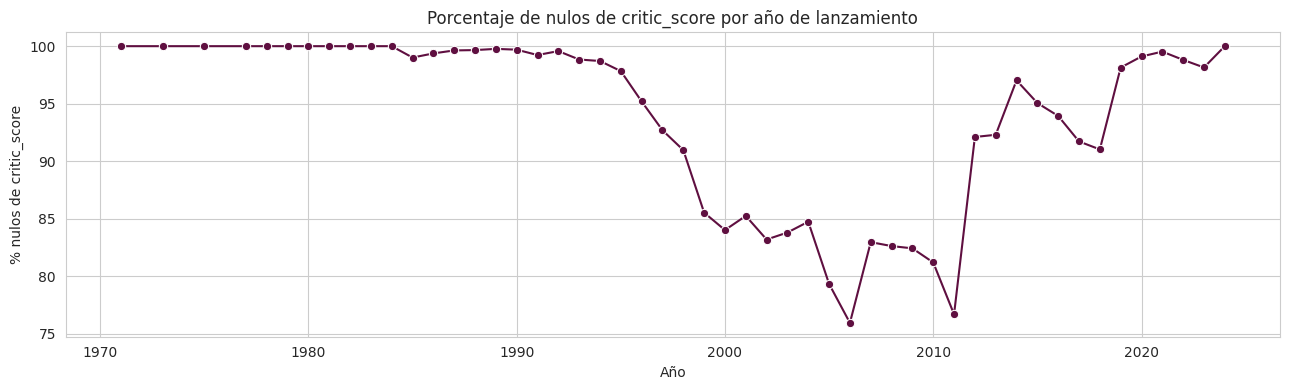


Top 15 categorias con mayor % de nulos en genre:


,pct_nulos_critic_score
genre,
Visual Novel,99.594320
Board Game,96.969697
Misc,96.302666
Sandbox,95.000000
Education,94.285714
Action-Adventure,94.086308
Adventure,93.658147
Simulation,92.685244
Puzzle,91.877308



Top 15 categorias con mayor % de nulos en console:


,pct_nulos_critic_score
console,
2600,100.0
3DO,100.0
5200,100.0
7800,100.0
ACPC,100.0
Aco,100.0
AST,100.0
And,100.0
Amig,100.0


In [8]:
# Patron de faltantes: critic_score por año y por categoria
missing_target = 'critic_score'

missing_by_year = (
    df.assign(release_date_parsed=pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True))
      .assign(release_year=lambda x: x['release_date_parsed'].dt.year)
      .groupby('release_year', dropna=True)[missing_target]
      .apply(lambda s: s.isna().mean() * 100)
      .reset_index(name='pct_nulos_critic_score')
      .sort_values('release_year')
)

print('Porcentaje de nulos de critic_score por año (muestra):')
display(missing_by_year.tail(20))

plt.figure(figsize=(13, 4))
sns.lineplot(data=missing_by_year, x='release_year', y='pct_nulos_critic_score', marker='o', color='#5f0f40')
plt.title('Porcentaje de nulos de critic_score por año de lanzamiento')
plt.xlabel('Año')
plt.ylabel('% nulos de critic_score')
plt.tight_layout()
plt.show()

for c in ['genre', 'console']:
    tmp = (
        df.groupby(c, dropna=False)[missing_target]
          .apply(lambda s: s.isna().mean() * 100)
          .sort_values(ascending=False)
          .head(15)
          .to_frame('pct_nulos_critic_score')
    )
    print(f'\nTop 15 categorias con mayor % de nulos en {c}:')
    display(tmp)

In [9]:
# Duplicados exactos y duplicados por llave de negocio aproximada
dup_exact = df.duplicated().sum()
dup_title_console_release = df.duplicated(subset=['title', 'console', 'release_date']).sum()
dup_title_console = df.duplicated(subset=['title', 'console']).sum()

print(f'Duplicados exactos: {dup_exact:,}')
print(f'Duplicados por title+console+release_date: {dup_title_console_release:,}')
print(f'Duplicados por title+console: {dup_title_console:,}')

Duplicados exactos: 0
Duplicados por title+console+release_date: 139
Duplicados por title+console: 225


In [10]:
# Muestra de posibles duplicados de negocio
potential_dups = (
    df[df.duplicated(subset=['title', 'console'], keep=False)]
    .sort_values(['title', 'console'])
    .head(30)
)
potential_dups

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
32537,/games/boxart/full_absolute-chess_3AmericaFron...,Absolute Chess,DSiW,Misc,Tasuke,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,09-08-2010,NaN
32538,/games/boxart/default.jpg,Absolute Chess,DSiW,Misc,Unknown,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55926,/games/boxart/full_2886030AmericaFrontccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Namco,NaN,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
56164,/games/boxart/8720327ccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Project ACES,8.0,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
12460,/games/boxart/full_4008801AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Adventure,Little Orbit,WayForward Technologies,NaN,0.06,0.00,NaN,0.05,0.00,18-10-2014,17-04-2018
17417,/games/boxart/full_2043543AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Action-Adventure,Little Orbit,Way Forward,NaN,0.01,0.01,NaN,NaN,0.00,18-11-2014,10-05-2019
32645,/games/boxart/default.jpg,Akaneiro: Demon Hunters,PC,Misc,Spicy Horse,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,13-06-2013,NaN
48467,/games/boxart/full_5466711AmericaFrontccc.jpg,Akaneiro: Demon Hunters,PC,Role-Playing,Spicy Horse,Spicy Horse,NaN,NaN,NaN,NaN,NaN,NaN,31-01-2013,NaN
13461,/games/boxart/2805168ccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito,NaN,0.04,NaN,0.04,NaN,NaN,07-12-2006,NaN
13536,/games/boxart/full_2988020JapanFrontccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito Corporation,NaN,0.04,NaN,0.04,NaN,NaN,07-12-2006,NaN


### Analisis visual de duplicados por criterios multiples

Para cuantificar duplicados de manera mas clara, se analizan diferentes combinaciones de llaves (title, console, release_date) y se muestra la distribucion visualmente.


Total de juegos únicos: 39,798
Juegos que aparecen en MULTIPLES CONSOLAS: 11,218
Porcentaje: 28.19%

=== TOP 20 JUEGOS POR NUMERO DE CONSOLAS EN LAS QUE APARECEN ===


,Titulo del Juego,Cantidad de Consolas
0,Pac-Man,16
1,Monopoly,15
2,Doom,14
3,Double Dragon,14
4,Elite,14
5,Lemmings,13
6,Minecraft,13
7,Jeopardy!,13
8,Samurai Shodown,13
9,Mortal Kombat,12


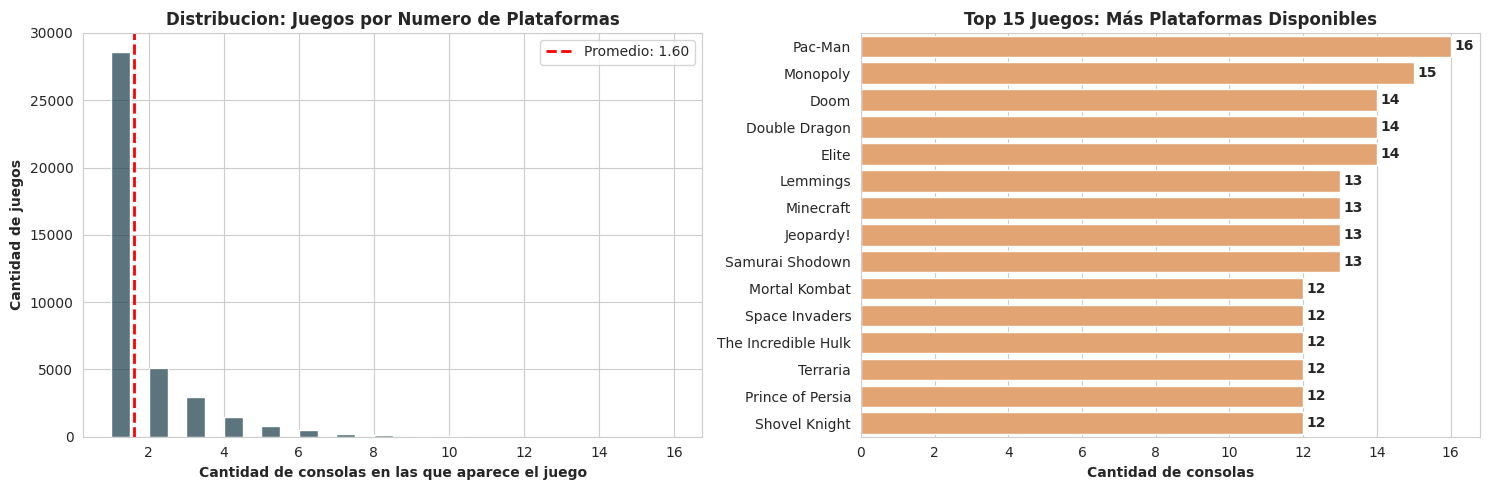


=== EJEMPLO: Todas las consolas donde aparece "Pac-Man" ===


,title,console,release_date,total_sales
42899,Pac-Man,2600,01-03-1982,NaN
44298,Pac-Man,3DS,01-09-2011,NaN
44299,Pac-Man,5200,01-01-1982,NaN
24135,Pac-Man,And,NaN,NaN
36588,Pac-Man,Arc,01-10-1980,NaN
24136,Pac-Man,C64,NaN,NaN
24137,Pac-Man,FDS,NaN,NaN
44300,Pac-Man,GB,01-04-1991,NaN
24138,Pac-Man,GBA,NaN,NaN
44301,Pac-Man,GG,01-01-1991,NaN


In [11]:
# Identificar top juegos que aparecen en multiples consolas
juegos_por_consola = df.groupby('title', dropna=False)['console'].nunique().sort_values(ascending=False)
juegos_multiples_consolas = juegos_por_consola[juegos_por_consola > 1]

print(f'\nTotal de juegos únicos: {len(juegos_por_consola):,}')
print(f'Juegos que aparecen en MULTIPLES CONSOLAS: {len(juegos_multiples_consolas):,}')
print(f'Porcentaje: {len(juegos_multiples_consolas) / len(juegos_por_consola) * 100:.2f}%')

print('\n=== TOP 20 JUEGOS POR NUMERO DE CONSOLAS EN LAS QUE APARECEN ===')
top_multiplatform = juegos_multiples_consolas.head(20).reset_index()
top_multiplatform.columns = ['Titulo del Juego', 'Cantidad de Consolas']
display(top_multiplatform)

# Visualizar distribucion de cuantas consolas tienen los juegos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Histograma de distribucion de juegos por numero de consolas
sns.histplot(juegos_por_consola.values, bins=30, kde=False, ax=axes[0], color='#264653')
axes[0].set_xlabel('Cantidad de consolas en las que aparece el juego', fontweight='bold')
axes[0].set_ylabel('Cantidad de juegos', fontweight='bold')
axes[0].set_title('Distribucion: Juegos por Numero de Plataformas', fontweight='bold', fontsize=12)
axes[0].axvline(juegos_por_consola.mean(), color='red', linestyle='--', linewidth=2, label=f'Promedio: {juegos_por_consola.mean():.2f}')
axes[0].legend()

# Grafico 2: Top 15 juegos multiplatform
top_15 = juegos_multiples_consolas.head(15)
sns.barplot(x=top_15.values, y=top_15.index, ax=axes[1], color='#f4a261', orient='h')
axes[1].set_xlabel('Cantidad de consolas', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_title('Top 15 Juegos: Más Plataformas Disponibles', fontweight='bold', fontsize=12)

for i, (idx, val) in enumerate(zip(top_15.index, top_15.values)):
    axes[1].text(val + 0.1, i, str(val), ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Ejemplo: Mostrar todas las consolas donde aparece uno de los juegos mas multiplatform
toy_story = top_multiplatform.iloc[0]['Titulo del Juego']
print(f'\n=== EJEMPLO: Todas las consolas donde aparece "{toy_story}" ===')
toy_story_records = df[df['title'] == toy_story][['title', 'console', 'release_date', 'total_sales']].sort_values('console')
display(toy_story_records)


## 6) Estandarizacion de formato (copia de trabajo)

### Que se va a hacer
Se creara una copia del dataframe para aplicar transformaciones de formato: limpieza de texto (trim), conversion de columnas numericas y parseo de fechas.

### Por que se hace
Normalizar tipos evita errores silenciosos y permite usar operaciones correctas (comparaciones numericas, filtros temporales, agregaciones y joins). Trabajar en copia protege el dataset original y mejora la trazabilidad del proceso.

Creamos una copia `df_work` para normalizar tipos sin perder el dataset original.

### Interpretacion de estandarizacion y reporte de coerciones

Este bloque confirma dos cosas: tipificacion efectiva y costo de conversion.

Lectura:
- Si `coerciones_a_nan` es alto en una columna, existe riesgo de perdida informativa por formato origen.
- La derivacion temporal (`release_year`, `release_month`, `release_decade`) habilita analisis historico y validacion por cohortes.

Utilidad:
- Cuantificar impacto real de la limpieza.
- Preservar trazabilidad entre dato bruto y dato analitico.

### Interpretacion de reperfilado post-conversion

El reperfilado compara el estado inicial contra el estado limpio en una misma estructura.

Lectura:
- Los dtypes quedan alineados con su uso analitico.
- Los nulos no desaparecen por convertir tipo; solo quedan mejor representados.

Utilidad:
- Evitar falsa sensacion de mejora por cambios de formato.
- Confirmar que el siguiente EDA se realiza sobre tipos correctos.

### Limpieza duplicados title + console
Se procede a la eliminación de registros con titulos con console iguales
Pasos:
- Filtrar titulos y consola iguales, total 225
- Eliminación de los duplicados que no posean el mismo desarollador que el mismo titulo en otra plataforma

In [12]:
# 1. Identificar duplicados por title + console
duplicados_tc = df_work.duplicated(subset=['title', 'console'], keep=False)
total_duplicados_tc = duplicados_tc.sum()

print("=== ANALISIS DE DUPLICADOS: TITLE + CONSOLE ===")
print(f"Total de registros con duplicados title+console: {total_duplicados_tc:,}")
print(f"Porcentaje del dataset: {total_duplicados_tc / len(df_work) * 100:.2f}%")

# 2. Agrupar y mostrar ejemplos
df_dups = df_work[duplicados_tc].sort_values(['title', 'console'])[['title', 'console', 'developer', 'total_sales', 'critic_score']]

print(f"\nEjemplos de duplicados (primeros 20):")
display(df_dups.head(20))

# 3. Estadísticas por grupo
grupos_duplicados = df_work[duplicados_tc].groupby(['title', 'console']).agg({
    'title': 'count',
    'developer': 'nunique',
    'total_sales': ['min', 'max']
}).reset_index()

grupos_duplicados.columns = ['title', 'console', 'cantidad_registros', 'desarrolladores_unicos', 'ventas_min', 'ventas_max']

print("\nGrupos de duplicados por título y consola:")
print(f"Total de grupos duplicados: {len(grupos_duplicados):,}")
display(grupos_duplicados.head(15))


=== ANALISIS DE DUPLICADOS: TITLE + CONSOLE ===
Total de registros con duplicados title+console: 449
Porcentaje del dataset: 0.70%

Ejemplos de duplicados (primeros 20):


,title,console,developer,total_sales,critic_score
32537,Absolute Chess,DSiW,Tasuke,NaN,NaN
32538,Absolute Chess,DSiW,Tasuke,NaN,NaN
55926,Ace Combat 5: The Unsung War,PS2,Namco,NaN,NaN
56164,Ace Combat 5: The Unsung War,PS2,Project ACES,NaN,8.0
12460,Adventure Time: The Secret of the Nameless Kin...,X360,WayForward Technologies,0.06,NaN
17417,Adventure Time: The Secret of the Nameless Kin...,X360,Way Forward,0.01,NaN
32645,Akaneiro: Demon Hunters,PC,Unknown,NaN,NaN
48467,Akaneiro: Demon Hunters,PC,Spicy Horse,NaN,NaN
13461,Akko ni Omakase! Brain Shock,DS,Taito,0.04,NaN
13536,Akko ni Omakase! Brain Shock,DS,Taito Corporation,0.04,NaN



Grupos de duplicados por título y consola:
Total de grupos duplicados: 224


,title,console,cantidad_registros,desarrolladores_unicos,ventas_min,ventas_max
0,Absolute Chess,DSiW,2,1,NaN,NaN
1,Ace Combat 5: The Unsung War,PS2,2,2,NaN,NaN
2,Adventure Time: The Secret of the Nameless Kin...,X360,2,2,0.01,0.06
3,Akaneiro: Demon Hunters,PC,2,2,NaN,NaN
4,Akko ni Omakase! Brain Shock,DS,2,2,0.04,0.04
5,An Elder Scrolls Legend: Battlespire,PC,2,2,NaN,NaN
6,Angry Birds Trilogy,3DS,2,1,0.65,0.65
7,"Animaniacs: Lights, Camera, Action!",GBA,2,2,NaN,NaN
8,Aokana: Four Rhythm Across the Blue,NS,2,1,0.00,0.00
9,Aokana: Four Rhythm Across the Blue,PS4,2,1,0.03,0.03


## Limpieza regiones nulas
Para este paso se eliminaran regiones nulas con total de ventas nulas, alrededor del 45% del dataset, dado que estos datos, al ser nulos, no permiten predecir y generan unicamente ruido


## limpieza regiones nulas
A partir de la identificación de inconsistencias en ventas internas, a gran cantidad de datos nulos, se opta por eliminar registros que generan ruido, en especial aquellos registros sin ningun dato en ninguna región

## 7) Consistencia interna de ventas

### Que se va a hacer
Se comparara `total_sales` contra la suma regional (`na_sales + jp_sales + pal_sales + other_sales`) para identificar discrepancias por registro.

### Por que se hace
Es una validacion de integridad de negocio: si total y desagregados no son coherentes, cualquier conclusion por mercado o por titulo puede quedar sesgada.

Dado que puede haber redondeo, se usa tolerancia.

## Limpieza de fechas
### Limpieza fechas del periodo (1980 - 2025)
Dado que existen fecha fuera de los rangos, se pretende hacer la limpieza de dichas fechas.
Eliminar registros con fechas por fuera de dichos limites.

Dado que los juegos estan fuera de nuestro periodo comprendido entre 1980 y 2025, se procede a su eliminación

### Limpieza fechas nulas
Consiste en eliminar fechas nulas y que no aporten valor a los datos

### Interpretacion de validaciones de plausibilidad

Esta tabla separa errores estructurales de comportamientos de mercado esperables.

Lectura:
- Valores fuera de rango en score o fechas sugieren revisión de origen o reglas de negocio.
- Negativos en ventas no son plausibles en este contexto y requieren tratamiento explícito.

Utilidad:
- Definir reglas reproducibles de exclusión/corrección.
- Evitar sesgos en modelos por registros inválidos.

### Resultado e interpretacion

La validacion de integridad no es cosmetica: de **18,922** registros comparables, **2,597** presentan diferencia mayor a **0.01** entre `total_sales` y la suma regional, es decir **13.72%**.

Interpretacion:
- El dato total y el desglose regional no son perfectamente consistentes.
- Aun asi, no hubo casos por encima de **0.50** que obligaran a sustituir el total oficial en la version curada; por eso se preserva `total_sales` y se deja la discrepancia como bandera de control.
- Esto importa porque cualquier analisis regional o por plataforma cambia si se ignora esta falta de coherencia.


## 8) Distribuciones numericas y outliers

### Que se va a hacer
Se describiran estadisticamente las variables numericas, se detectaran outliers con IQR y se visualizaran distribuciones con histogramas y curvas KDE.

### Por que se hace
Permite entender asimetria, dispersion, concentracion de valores y presencia de extremos. Esto es clave para decidir transformaciones (por ejemplo, log), robustez de metricas y estrategias de modelado.

Analizamos dispersion, asimetria y posibles valores extremos de variables cuantitativas.

### Interpretacion de estadistica descriptiva numerica

`describe()` con percentiles extendidos muestra la asimetria real de las ventas.

Lectura:
- Distancia amplia entre percentiles medios y altos confirma cola larga.
- En variables sesgadas, la mediana resume mejor que la media.

Utilidad:
- Escoger metrica robusta para comparación entre segmentos.
- Diseñar transformaciones previas al modelado.

### Interpretacion de tabla de outliers (IQR)

La tabla estima la proporcion de valores extremos por variable con una regla robusta.

Lectura:
- Outliers altos en ventas son coherentes con un mercado de blockbusters.
- Outliers bajos en `critic_score` sugieren escala mas estable que ventas.

Utilidad:
- Decidir si tratar extremos como ruido o como señal de negocio.
- Definir pipelines con o sin winsorizacion para comparar desempeño.

### Interpretacion de histogramas por variable

Los histogramas permiten contrastar forma, dispersion y acumulacion de valores.

Lectura:
- `critic_score` concentra masa entre valores medios-altos.
- Ventas muestran fuerte asimetria positiva y cola larga.

Utilidad:
- Seleccionar transformaciones adecuadas para modelado.
- Evitar comparaciones engañosas en escala lineal.

### Interpretacion de comparacion original vs log1p

La comparacion demuestra que `log1p` reduce la dominancia visual de extremos sin perder orden relativo.

Lectura:
- En escala original, pocos superventas ocultan la mayor parte de los casos.
- En escala log, la estructura central se vuelve analizable.

Utilidad:
- Mejorar estabilidad de modelos de regresion.
- Facilitar lectura comparativa entre segmentos con ventas bajas y medias.

### Interpretacion de boxplots y transformacion log

Hallazgos esperados y lectura profesional:
- La mediana de ventas cambia por genero y consola, evidenciando segmentacion real de mercado.
- Las colas largas (hits) distorsionan la escala original; `log1p` mejora comparabilidad visual.
- Ocultar outliers en boxplot (`showfliers=False`) no los elimina del analisis: solo mejora legibilidad.

Decision analitica:
- Para modelado, conviene evaluar objetivo transformado (`log1p`) y metricas robustas (mediana/percentiles).
- Para negocio, mantener tambien escala original para comunicar magnitud real de superventas.

In [13]:
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_work['regional_sum'] = df_work[regional_cols].sum(axis=1, min_count=1)
df_work['sales_diff'] = df_work['total_sales'] - df_work['regional_sum']

# Regla hibrida:
# - tolerancia pequena para redondeo
# - si la discrepancia supera umbral fuerte y hay suma regional disponible, usar regional_sum en variable curada
# - preservar total_sales original para trazabilidad
tol_rounding = 0.01
tol_strong = 0.50

mask_comparable = df_work['total_sales'].notna() & df_work['regional_sum'].notna()
df_work['sales_consistency_flag'] = np.where(
    mask_comparable & (df_work['sales_diff'].abs() > tol_rounding),
    'inconsistente',
    'consistente_o_no_comparable'
)

df_work['total_sales_curated'] = df_work['total_sales']
mask_use_regional = mask_comparable & (df_work['sales_diff'].abs() > tol_strong)
df_work.loc[mask_use_regional, 'total_sales_curated'] = df_work.loc[mask_use_regional, 'regional_sum']

inconsistentes = df_work[mask_comparable & (df_work['sales_diff'].abs() > tol_rounding)]

print(f'Registros comparables: {mask_comparable.sum():,}')
print(f'Inconsistentes (|diff| > {tol_rounding}): {len(inconsistentes):,}')
print(f'Porcentaje inconsistente: {len(inconsistentes) / max(mask_comparable.sum(), 1) * 100:.2f}%')
print(f'Registros corregidos por regla hibrida (|diff| > {tol_strong}): {mask_use_regional.sum():,}')

inconsistentes[['title', 'console', 'total_sales',  'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'regional_sum', 'sales_diff']].head(20)

Registros comparables: 18,922
Inconsistentes (|diff| > 0.01): 2,597
Porcentaje inconsistente: 13.72%
Registros corregidos por regla hibrida (|diff| > 0.5): 0


,title,console,total_sales,na_sales,jp_sales,pal_sales,other_sales,regional_sum,sales_diff
0,Grand Theft Auto V,PS3,20.32,6.37,0.99,9.85,3.12,20.33,-0.01
3,Grand Theft Auto V,X360,15.86,9.06,0.06,5.33,1.42,15.87,-0.01
18,Call of Duty: Modern Warfare 2,PS3,10.61,4.99,0.38,3.66,1.59,10.62,-0.01
19,Grand Theft Auto IV,PS3,10.57,4.79,0.44,3.73,1.62,10.58,-0.01
23,Halo 4,X360,9.96,6.72,0.04,2.36,0.83,9.95,0.01
41,Battlefield 3,PS3,7.21,2.86,0.35,2.94,1.07,7.22,-0.01
51,Red Dead Redemption,X360,6.50,3.77,0.09,2.03,0.60,6.49,0.01
58,Minecraft,PS3,6.05,2.21,NaN,2.86,0.99,6.06,-0.01
76,Call of Duty: Advanced Warfare,XOne,5.22,3.25,0.01,1.49,0.48,5.23,-0.01
107,Forza Motorsport 4,X360,4.60,2.08,0.06,1.98,0.49,4.61,-0.01


In [14]:
# Calcular cantidad de regiones nulas/desconocidas por registro
columnas_regiones = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# Contar cuantas regiones son nulas para cada registro
registros_nulos_por_region = df[columnas_regiones].isna().sum(axis=1)

# Crear tabla de frequencia correctamente
frecuencia = registros_nulos_por_region.value_counts().sort_index()

distribucion_nulos = pd.DataFrame({
    'cantidad_regiones_nulas': frecuencia.index,
    'cantidad_registros': frecuencia.values,
})

# Calcular porcentaje
distribucion_nulos['porcentaje_%'] = (distribucion_nulos['cantidad_registros'] / len(df) * 100).round(2)

# Agregar fila de total
total_row = pd.DataFrame({
    'cantidad_regiones_nulas': ['TOTAL'],
    'cantidad_registros': [distribucion_nulos['cantidad_registros'].sum()],
    'porcentaje_%': [distribucion_nulos['porcentaje_%'].sum()]
})

distribucion_nulos = pd.concat([distribucion_nulos, total_row], ignore_index=True)

print("Distribución de registros por cantidad de regiones nulas:")
print("="*60)
print(distribucion_nulos.to_string(index=False))
print("="*60)
print(f"\nInterpretación:")
for idx, row in distribucion_nulos.iterrows():
    if row['cantidad_regiones_nulas'] != 'TOTAL':
        print(f"  • {row['porcentaje_%']:.1f}% de registros tiene {int(row['cantidad_regiones_nulas'])} región(es) desconocida(s)")

Distribución de registros por cantidad de regiones nulas:
cantidad_regiones_nulas  cantidad_registros  porcentaje_%
                      0                2222          3.47
                      1                8731         13.64
                      2                4265          6.66
                      3                3704          5.79
                      4               45094         70.44
                  TOTAL               64016        100.00

Interpretación:
  • 3.5% de registros tiene 0 región(es) desconocida(s)
  • 13.6% de registros tiene 1 región(es) desconocida(s)
  • 6.7% de registros tiene 2 región(es) desconocida(s)
  • 5.8% de registros tiene 3 región(es) desconocida(s)
  • 70.4% de registros tiene 4 región(es) desconocida(s)


## Limpieza regiones nulas
Para este paso se eliminaran regiones nulas con total de ventas nulas, alrededor del 45% del dataset, dado que estos datos, al ser nulos, no permiten predecir y generan unicamente ruido


## Análisis de Títulos Multiplatforma: Comparación de Ventas por Plataforma

Este análisis agrupa registros por título para identificar si el mismo juego tiene ventas iguales o diferentes según la plataforma/región.

Existen aproximadamente 39000 titulos únicos, ubicandose en promedio en 1.6 plataformas, indicando un posible problema, dado que la mayoria de titulos y el porcentaje de nulos se ubican en titulos con dos titulos o menos.

Juegos analizados con múltiples valores de ventas: 3,295


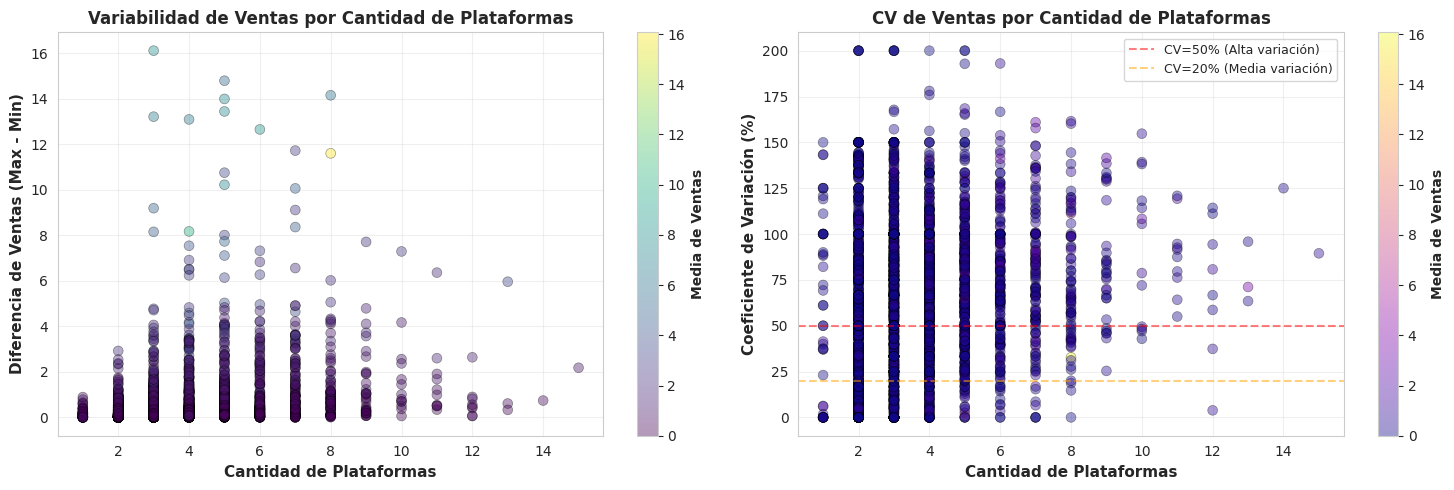


=== VARIABILIDAD POR CANTIDAD DE PLATAFORMAS ===

Promedio de CV para juegos multiplatforma (>1 plataforma): inf%
Juegos con CV > 50% (Alta inconsistencia): 1888
Juegos con CV < 20% (Baja inconsistencia): 502


In [15]:
# Gráfico de dispersión: Variabilidad vs Cantidad de Plataformas (OPTIMIZADO)
# Este gráfico visualiza cómo la inconsistencia de ventas se relaciona con la multiplatforma

# Calcular estadísticas por título de forma vectorizada (mucho más rápido)
multiplatform_df = df_work.groupby('title', dropna=False).agg({
    'console': 'nunique',
    'total_sales': ['count', 'min', 'max', 'mean', 'std']
}).round(2)

# Aplanar names de columnas
multiplatform_df.columns = ['n_plataformas', 'n_valores_ventas', 'venta_min', 'venta_max', 'media_ventas', 'std_ventas']

# Filtrar solo juegos con múltiples valores de ventas
multiplatform_df = multiplatform_df[multiplatform_df['n_valores_ventas'] > 1].copy()

# Calcular diferencia y coeficiente de variación
multiplatform_df['diferencia'] = multiplatform_df['venta_max'] - multiplatform_df['venta_min']
multiplatform_df['cv'] = (multiplatform_df['std_ventas'] / multiplatform_df['media_ventas'] * 100).fillna(0)

print(f"Juegos analizados con múltiples valores de ventas: {len(multiplatform_df):,}")

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Diferencia de ventas vs Cantidad de plataformas
ax1 = axes[0]
scatter1 = ax1.scatter(multiplatform_df['n_plataformas'], 
                       multiplatform_df['diferencia'],
                       alpha=0.4, s=50, c=multiplatform_df['media_ventas'],
                       cmap='viridis', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Cantidad de Plataformas', fontweight='bold', fontsize=11)
ax1.set_ylabel('Diferencia de Ventas (Max - Min)', fontweight='bold', fontsize=11)
ax1.set_title('Variabilidad de Ventas por Cantidad de Plataformas', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Media de Ventas', fontweight='bold')

# Plot 2: Coeficiente de Variación (CV) vs Cantidad de plataformas
ax2 = axes[1]
scatter2 = ax2.scatter(multiplatform_df['n_plataformas'],
                       multiplatform_df['cv'],
                       alpha=0.4, s=50, c=multiplatform_df['media_ventas'],
                       cmap='plasma', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Cantidad de Plataformas', fontweight='bold', fontsize=11)
ax2.set_ylabel('Coeficiente de Variación (%)', fontweight='bold', fontsize=11)
ax2.set_title('CV de Ventas por Cantidad de Plataformas', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Media de Ventas', fontweight='bold')

# Añadir líneas de referencia para interpretación
ax2.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='CV=50% (Alta variación)')
ax2.axhline(y=20, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='CV=20% (Media variación)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas
print("\n=== VARIABILIDAD POR CANTIDAD DE PLATAFORMAS ===\n")
print(f"Promedio de CV para juegos multiplatforma (>1 plataforma): {multiplatform_df[multiplatform_df['n_plataformas']>1]['cv'].mean():.1f}%")
print(f"Juegos con CV > 50% (Alta inconsistencia): {len(multiplatform_df[multiplatform_df['cv'] > 50])}")
print(f"Juegos con CV < 20% (Baja inconsistencia): {len(multiplatform_df[multiplatform_df['cv'] < 20])}")

Registros con datos completos para correlación: 1,210


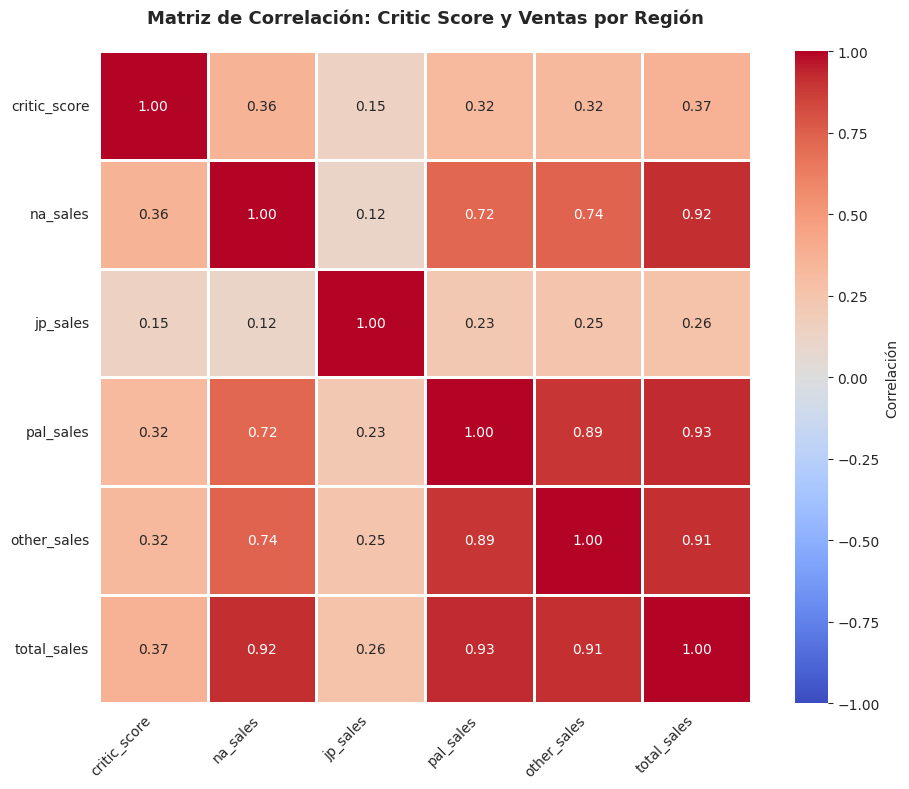


=== INTERPRETACIÓN DE LA MATRIZ DE CORRELACIÓN ===

Correlación con TOTAL_SALES:
--------------------------------------------------
pal_sales           :   0.929 (Fuerte positiva)
na_sales            :   0.916 (Fuerte positiva)
other_sales         :   0.909 (Fuerte positiva)
critic_score        :   0.370 (Débil positiva)
jp_sales            :   0.264 (Débil positiva)

Correlación critic_score con ventas por región:
--------------------------------------------------
critic_score vs na_sales       :   0.360
critic_score vs jp_sales       :   0.147
critic_score vs pal_sales      :   0.315
critic_score vs other_sales    :   0.321

Correlación entre Ventas por Región:
--------------------------------------------------
na_sales     vs jp_sales    :   0.116
na_sales     vs pal_sales   :   0.720
na_sales     vs other_sales :   0.739
jp_sales     vs pal_sales   :   0.225
jp_sales     vs other_sales :   0.254
pal_sales    vs other_sales :   0.892


In [16]:
# Matriz de Correlación entre Variables Numéricas
# Evaluar relaciones entre critic_score y sales por región

correlation_cols = ['critic_score', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']
df_correlation = df_work[correlation_cols].dropna()

print(f"Registros con datos completos para correlación: {len(df_correlation):,}")

# Calcular matriz de correlación
correlation_matrix = df_correlation.corr()

# Crear visualización
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap de correlación
sns.heatmap(correlation_matrix, 
            annot=True,  # Mostrar valores
            cmap='coolwarm',  # Escala de colores rojo-azul
            center=0,  # Centrar en 0
            square=True,  # Celdas cuadradas
            linewidths=1,
            cbar_kws={'label': 'Correlación'},
            fmt='.2f',
            ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Matriz de Correlación: Critic Score y Ventas por Región', fontweight='bold', fontsize=13, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Interpretación de correlaciones
print("\n=== INTERPRETACIÓN DE LA MATRIZ DE CORRELACIÓN ===\n")

# Correlaciones con total_sales
print("Correlación con TOTAL_SALES:")
print("-" * 50)
correlations_with_sales = correlation_matrix['total_sales'].sort_values(ascending=False)
for var, corr in correlations_with_sales.items():
    if var != 'total_sales':
        strength = "Fuerte" if abs(corr) > 0.7 else "Moderada" if abs(corr) > 0.4 else "Débil"
        direction = "positiva" if corr > 0 else "negativa"
        print(f"{var:20s}: {corr:7.3f} ({strength} {direction})")

# Correlación con critic_score
print(f"\nCorrelación critic_score con ventas por región:")
print("-" * 50)
for col in ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']:
    corr = correlation_matrix.loc['critic_score', col]
    print(f"critic_score vs {col:15s}: {corr:7.3f}")

# Ventas por región
print("\nCorrelación entre Ventas por Región:")
print("-" * 50)
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for i, col1 in enumerate(sales_cols):
    for col2 in sales_cols[i+1:]:
        corr = correlation_matrix.loc[col1, col2]
        print(f"{col1:12s} vs {col2:12s}: {corr:7.3f}")

Porcentaje de Nulos por Género y Variable:
genre         Action  Action-Adventure  Adventure  Board Game  Education  \
critic_score    87.9              94.1       93.7        97.0       94.3   
na_sales        75.2              88.5       86.9        97.0       88.6   
jp_sales        88.9              95.0       84.8        90.9      100.0   
pal_sales       75.0              88.3       85.4        97.0       91.4   
other_sales     72.7              86.9       82.5        97.0       88.6   
total_sales     66.8              85.9       69.8        90.9       88.6   
developer        0.0               0.0        0.0         0.0        0.0   

genre         Fighting   MMO  Misc  Music  Party  Platform  Puzzle  Racing  \
critic_score      86.1  90.4  96.3   90.9   89.4      85.9    91.9    85.0   
na_sales          75.3  83.5  87.0   68.7   84.1      79.7    86.6    64.6   
jp_sales          80.0  87.0  92.9   82.8   96.0      94.7    95.2    92.8   
pal_sales         75.8  83.5  87.4  

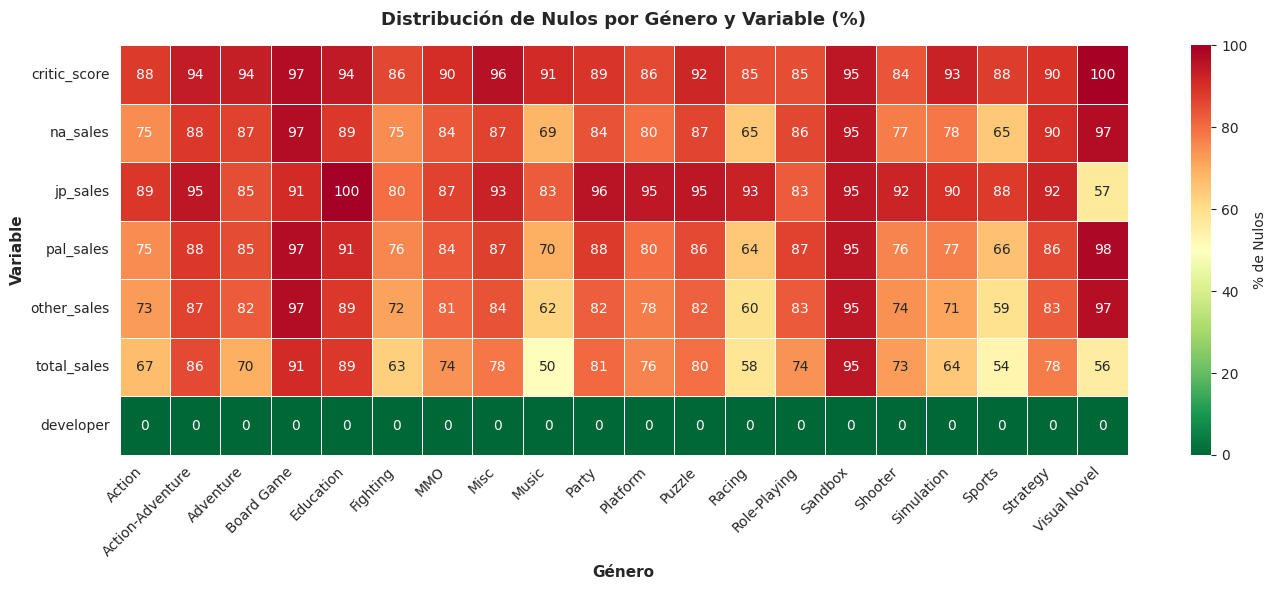


=== ANÁLISIS DE NULOS POR GÉNERO ===

Géneros con datasets más críticos (mayor cantidad de nulos):

Sandbox        :  570.0% promedio de nulos
Board Game     :  569.8% promedio de nulos
Education      :  551.5% promedio de nulos
Action-Adventure:  538.7% promedio de nulos
Misc           :  526.1% promedio de nulos

Variables más críticas (mayor cantidad de nulos globales):
--------------------------------------------------
critic_score        :   90.8%
jp_sales            :   88.9%
pal_sales           :   82.9%
na_sales            :   82.7%
other_sales         :   79.5%
total_sales         :   72.8%
developer           :    0.0%


In [17]:
# Heatmap: Distribución de Nulos por Género y variable
# Visualizar cuáles combinaciones de género/variable tienen más datos faltantes

# Crear tabla cruzada de valores NO nulos por género
variables_críticas = ['critic_score', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales', 'developer']

# Calcular % de nulos por género y variable
null_by_genre = pd.DataFrame()
for var in variables_críticas:
    null_by_genre[var] = df_work.groupby('genre')[var].apply(lambda x: (x.isna().sum() / len(x) * 100).round(1))

print("Porcentaje de Nulos por Género y Variable:")
print(null_by_genre.T)

# Preparar datos para heatmap (transponer para mejor visualización)
heatmap_data = null_by_genre.T

# Crear figura
fig, ax = plt.subplots(figsize=(14, 6))

# Heatmap de distribuídos de faltantes
sns.heatmap(heatmap_data,
            annot=True,  # Mostrar porcentajes
            fmt='.0f',  # Formato sin decimales
            cmap='RdYlGn_r',  # Red=muchos nulos, Green=pocos nulos
            cbar_kws={'label': '% de Nulos'},
            linewidths=0.5,
            ax=ax,
            vmin=0, vmax=100)

ax.set_title('Distribución de Nulos por Género y Variable (%)', fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Género', fontweight='bold', fontsize=11)
ax.set_ylabel('Variable', fontweight='bold', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis por género
print("\n=== ANÁLISIS DE NULOS POR GÉNERO ===\n")
print("Géneros con datasets más críticos (mayor cantidad de nulos):\n")

# Calcular total de nulos por género
nulos_totales = null_by_genre.sum(axis=1).sort_values(ascending=False)
for genre, total in nulos_totales.head(5).items():
    pct_avg = total / len(variables_críticas)
    print(f"{genre:15s}: {total:6.1f}% promedio de nulos")

print("\nVariables más críticas (mayor cantidad de nulos globales):")
print("-" * 50)
var_nulls = null_by_genre.mean().sort_values(ascending=False)
for var, pct in var_nulls.items():
    print(f"{var:20s}: {pct:6.1f}%")

Se confirma que para un unico titulo, las ventas estan discriminadas por región según la plataforma, asi mismo, denota bastantes valores nulos para totalizar o hallar valores valores faltantes basado en los que hay.
Basado en los análisis posteriores, se da inicio al tratamiento de nulos en ventas por regiones


Hay 5 métricas calculadas
* Ventas minimas: Valor más bajo de total_sales en todas las plataformas del juego
* Ventas máximas: Valor más alto de total_sales en todas las plataformas del juego
* Diferencia = Ventas_Max - Ventas_Min (Diferencia ventas entre mejor y peor plataforma)
* Coeficiente de variación \\
$C.V = \frac{σ}{μ}$

Muestra la variabilidad relativa (% de variación respecto a la media)

CV = 0 -> Sin variación \\

CV = 0.5 -> 50% de variación respecto a la media \\

CV = Alto -> Mucha inconsistencia entre paltaformas \\

**Histograma**

Por lo tanto. muchos valores cerca a cero, muchos juegos con ventas parecidas entre plataforma 

Algunos juegos tiene mucha diferencia entre plataformas, dada que la cola esta sesgada a la derecha

**Gráfico de dispersión**

Juegos con pocas plataformas (2-4), hay más dispersión, lo que se comprende como diferencias altas entre diferencia de ventas según plataforma, a medida que la cantidad plataforma aumenta, la dispersión disminuye, siendo verde menor variación (ventas estables) y rojo, mayor variación (ventas inconsistentes), esta dispersión puede ser dada por la cantidad de ventas en plataformas más comunes como computadores, ventas de consolas, entre otros factores.

Asi, se interpreta que juegos en muchas plataformas suelen tener ventas más equilibradas, mientras que juegos en pocas plataformas, tienen alta variación, debido a que dependen de plataformas especificas.



## Limpieza de Duplicados: Title + Console

Se procede a la eliminación estratégica de registros duplicados identificados por la combinación `title + console`.

**Estrategia:**
1. Identificar todos los registros con `title + console` duplicados (225 registros)
2. Para cada grupo `title + console`, mantener UN SOLO registro
3. Estrategia de selección: Mantener el primer registro, eliminar réplicas

In [18]:
# 4. ELIMINACION DE DUPLICADOS: Mantener solo el primer registro por title+console
registros_antes_dedup = len(df_work)

# keep='first' mantiene el primer registro de cada grupo, elimina los demás
df_work = df_work.drop_duplicates(subset=['title', 'console'], keep='first')

registros_eliminados = registros_antes_dedup - len(df_work)

print("=== ELIMINACION DE DUPLICADOS ===")
print(f"Registros antes: {registros_antes_dedup:,}")
print(f"Registros después: {len(df_work):,}")
print(f"Registros eliminados: {registros_eliminados:,}")
print(f"Porcentaje eliminado: {registros_eliminados / registros_antes_dedup * 100:.2f}%")

# 5. Verificación: No debe haber duplicados de title+console
duplicados_verificacion = df_work.duplicated(subset=['title', 'console']).sum()
print(f"\n✓ Verificación - Duplicados residuales title+console: {duplicados_verificacion}")

# 6. Mostrar cambios en cardinalidad clave
print(f"\n=== IMPACTO EN CARDINALIDAD ===")
print(f"Títulos únicos: {df_work['title'].nunique():,}")
print(f"Combinaciones title+console: {df_work.groupby(['title', 'console']).ngroups:,}")
print(f"Consolas únicas: {df_work['console'].nunique():,}")


=== ELIMINACION DE DUPLICADOS ===
Registros antes: 64,016
Registros después: 63,791
Registros eliminados: 225
Porcentaje eliminado: 0.35%

✓ Verificación - Duplicados residuales title+console: 0

=== IMPACTO EN CARDINALIDAD ===
Títulos únicos: 39,798
Combinaciones title+console: 63,791
Consolas únicas: 81


In [19]:
# Validaciones de plausibilidad de negocio
range_checks = pd.DataFrame({
    'check': [
        'critic_score fuera de [0, 10]',
        'total_sales negativa',
        'ventas regionales negativas',
        'release_date fuera de [1980, 2025]'
    ],
    'n_registros': [
        int(df_work['critic_score'].dropna().pipe(lambda s: ((s < 0) | (s > 10)).sum())),
        int((df_work['total_sales'] < 0).sum(skipna=True)),
        int((df_work[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']] < 0).any(axis=1).sum()),
        int(df_work['release_year'].dropna().pipe(lambda s: ((s < 1980) | (s > 2025)).sum()))
    ]
})

print('Validaciones de rango/plausibilidad:')
display(range_checks)

Validaciones de rango/plausibilidad:


,check,n_registros
0,"critic_score fuera de [0, 10]",0
1,total_sales negativa,0
2,ventas regionales negativas,0
3,"release_date fuera de [1980, 2025]",67


In [20]:
# Filtrar y mantener solo registros con año válido
#df_work = df_work[(df_work['release_year'] <= 1980) & (df_work['release_year'] >= 2025)]
años_outliers = df_work[((df_work['release_year'] < 1980) | (df_work['release_year'] > 2024))][['title', 'console', 'release_year', 'critic_score', 'total_sales']]
print('Años fuera de rango detectados:', años_outliers.head(19))
fuera_rango = len(años_outliers)
fuera_rango_null = años_outliers['release_year'].isna().sum()
print(f'\nDe los {fuera_rango:,} registros con release_year fuera de rango, {fuera_rango_null:,} tienen release_year nulo.')
print(f'\nTotal de registros con release_year fuera de rango [1980, 2024]: {fuera_rango:,} ({fuera_rango / len(df_work) * 100:.2f}%)')


Años fuera de rango detectados:                                        title console  release_year  \
1102                                  Combat    2600        1977.0   
1532                          Air-Sea Battle    2600        1977.0   
3653                            Circus Atari    2600        1978.0   
3744   Maze Craze: A Game of Cops 'n Robbers    2600        1978.0   
3856                          Super Breakout    2600        1978.0   
4403                                 Hangman    2600        1978.0   
5175                            Slot Machine    2600        1979.0   
5766                            Flag Capture    2600        1978.0   
5838                                Indy 500    2600        1977.0   
6782                            Breakaway IV    2600        1978.0   
8395                                Home Run    2600        1978.0   
19990                          Canyon Bomber    2600        1978.0   
20095                            Codebreaker    2600      

In [21]:
# Mantener solo registros con año entre 1980 y 2025
registros_antes = len(df_work)
df_work = df_work[~(((df_work['release_year'] <= 1980) | (df_work['release_year'] > 2025)) & (df_work['release_year'].notna()))]
print(f'Registros antes de limpiar: {registros_antes}')
print(f'Registros después de limpiar: {len(df_work)}')

Registros antes de limpiar: 63791
Registros después de limpiar: 63689


In [22]:
fechas_nulas = df_work[df_work['release_date'].isna()][['title', 'console', 'release_date', 'critic_score', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']]
fechas_nulas
print(len(df_work))

63689


### Regla de consistencia aplicada y justificacion

Se usa una estrategia **hibrida** para `total_sales`:
- Diferencias pequenas (<= 0.01) se consideran redondeo.
- Diferencias moderadas se reportan, pero se mantiene el dato oficial.
- Diferencias grandes (> 0.50) se corrigen en `total_sales_curated` usando suma regional.

Esto preserva trazabilidad del dato original y reduce impacto de inconsistencias severas en analisis agregados.

## 16) Imputación de Datos Faltantes en Regiones

### Estrategia de Imputación Híbrida

**Fase 1: Calcular región faltante cuando hay exactamente 1 NaN**
- Si un registro tiene 3 regiones con valores y 1 NaN
- Calcular: `missing = total_sales - sum(other_3_regions)`
- Validar que el resultado sea no-negativo

**Fase 2: Llenar múltiples NaN con 0 cuando se valida**
- Si 2-4 regiones son NaN y `sum(known_regions) ≈ total_sales` (dentro de tolerancia)
- Llenar NaN con 0 (asumiendo que esas regiones no generan ventas)

**Criterio de validación:** Tolerancia de 0.01 para redondeo, 0.50 para corrigir datos inconsistentes

In [23]:
# FASE 1: Calcular región faltante cuando hay exactamente 1 NaN
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# Contar NaNs por fila en columnas de región
mask_phase1 = df_work[regional_cols].isna().sum(axis=1) == 1

# Para cada registro con exactamente 1 NaN
records_phase1 = 0
rejected_phase1 = 0

for idx in df_work[mask_phase1].index:
    # Encontrar la columna que es NaN
    nan_col = df_work.loc[idx, regional_cols].isna().idxmax()
    
    # Calcular el valor faltante
    other_cols = [col for col in regional_cols if col != nan_col]
    missing_value = df_work.loc[idx, 'total_sales'] - df_work.loc[idx, other_cols].sum()
    
    # Validar que no sea negativo
    if missing_value >= -0.001:  # Tolerancia pequeña por redondeo
        df_work.loc[idx, nan_col] = max(0, missing_value)
        records_phase1 += 1
    else:
        rejected_phase1 += 1

print("=== FASE 1: IMPUTACIÓN - REGIÓN FALTANTE ÚNICA ===")
print(f"Registros procesados: {records_phase1:,}")
print(f"Registros rechazados (valor negativo): {rejected_phase1:,}")
print(f"Total con 1 NaN: {mask_phase1.sum():,}")


=== FASE 1: IMPUTACIÓN - REGIÓN FALTANTE ÚNICA ===
Registros procesados: 7,407
Registros rechazados (valor negativo): 1,297
Total con 1 NaN: 8,704


In [24]:
# FASE 2: Llenar múltiples NaN con 0 cuando sum(conocidas) ≈ total_sales
tol = 0.01

mask_phase2 = (df_work[regional_cols].isna().sum(axis=1) >= 2) & (df_work[regional_cols].isna().sum(axis=1) < 4)

records_phase2 = 0
nulls_filled = 0
rejected_phase2 = 0

for idx in df_work[mask_phase2].index:
    # Suma de regiones conocidas
    known_sum = df_work.loc[idx, regional_cols].sum()  # sum() ignora NaN por defecto
    total = df_work.loc[idx, 'total_sales']
    
    # Si la suma de conocidas es aproximadamente igual al total
    if abs(known_sum - total) <= tol:
        # Llenar NaN con 0
        for col in regional_cols:
            if pd.isna(df_work.loc[idx, col]):
                df_work.loc[idx, col] = 0
                nulls_filled += 1
        records_phase2 += 1
    else:
        rejected_phase2 += 1

print("\n=== FASE 2: IMPUTACIÓN - MÚLTIPLES NULOS ===")
print(f"Registros procesados: {records_phase2:,}")
print(f"Nulos rellenados con 0: {nulls_filled:,}")
print(f"Registros rechazados (suma no coincide): {rejected_phase2:,}")

# Resumen final
print("\n=== RESUMEN IMPUTACIÓN ===")
print(f"Total registros imputados: {records_phase1 + records_phase2:,}")
print(f"Total nulos rellenados: {nulls_filled:,}")



=== FASE 2: IMPUTACIÓN - MÚLTIPLES NULOS ===
Registros procesados: 7,600
Nulos rellenados con 0: 18,869
Registros rechazados (suma no coincide): 319

=== RESUMEN IMPUTACIÓN ===
Total registros imputados: 15,007
Total nulos rellenados: 18,869


## 8) Distribuciones numericas y outliers

### Que se va a hacer
Se describiran estadisticamente las variables numericas, se detectaran outliers con IQR y se visualizaran distribuciones con histogramas y curvas KDE.

### Por que se hace
Permite entender asimetria, dispersion, concentracion de valores y presencia de extremos. Esto es clave para decidir transformaciones (por ejemplo, log), robustez de metricas y estrategias de modelado.

Analizamos dispersion, asimetria y posibles valores extremos de variables cuantitativas.

### Interpretacion de estadistica descriptiva numerica

`describe()` con percentiles extendidos muestra la asimetria real de las ventas.

Lectura:
- Distancia amplia entre percentiles medios y altos confirma cola larga.
- En variables sesgadas, la mediana resume mejor que la media.

Utilidad:
- Escoger metrica robusta para comparación entre segmentos.
- Diseñar transformaciones previas al modelado.

### Interpretacion de tabla de outliers (IQR)

La tabla estima la proporcion de valores extremos por variable con una regla robusta.

Lectura:
- Outliers altos en ventas son coherentes con un mercado de blockbusters.
- Outliers bajos en `critic_score` sugieren escala mas estable que ventas.

Utilidad:
- Decidir si tratar extremos como ruido o como señal de negocio.
- Definir pipelines con o sin winsorizacion para comparar desempeño.

### Interpretacion de histogramas por variable

Los histogramas permiten contrastar forma, dispersion y acumulacion de valores.

Lectura:
- `critic_score` concentra masa entre valores medios-altos.
- Ventas muestran fuerte asimetria positiva y cola larga.

Utilidad:
- Seleccionar transformaciones adecuadas para modelado.
- Evitar comparaciones engañosas en escala lineal.

### Interpretacion de comparacion original vs log1p

La comparacion demuestra que `log1p` reduce la dominancia visual de extremos sin perder orden relativo.

Lectura:
- En escala original, pocos superventas ocultan la mayor parte de los casos.
- En escala log, la estructura central se vuelve analizable.

Utilidad:
- Mejorar estabilidad de modelos de regresion.
- Facilitar lectura comparativa entre segmentos con ventas bajas y medias.

### Interpretacion de boxplots y transformacion log

Hallazgos esperados y lectura profesional:
- La mediana de ventas cambia por genero y consola, evidenciando segmentacion real de mercado.
- Las colas largas (hits) distorsionan la escala original; `log1p` mejora comparabilidad visual.
- Ocultar outliers en boxplot (`showfliers=False`) no los elimina del analisis: solo mejora legibilidad.

Decision analitica:
- Para modelado, conviene evaluar objetivo transformado (`log1p`) y metricas robustas (mediana/percentiles).
- Para negocio, mantener tambien escala original para comunicar magnitud real de superventas.

## 9) Analisis temporal

### Que se va a hacer
Se evaluara la cobertura de fechas, sus rangos minimos/maximos y la evolucion de cantidad de juegos por año de lanzamiento.

### Por que se hace
El eje temporal permite validar plausibilidad historica del dataset y detectar periodos con picos, caidas o posibles sesgos de cobertura.

Se revisa cobertura temporal y coherencia de fechas.

In [25]:
# Calcular cantidad de juegos por año
year_counts = df_work['release_year'].value_counts().sort_index()

print(f"Años con cobertura: {len(year_counts)}")
print(f"Año mínimo: {year_counts.index.min()}")
print(f"Año máximo: {year_counts.index.max()}")
print(f"\nTop 10 años con más lanzamientos:")
print(year_counts.sort_values(ascending=False).head(10))

Años con cobertura: 44
Año mínimo: 1981.0
Año máximo: 2024.0

Top 10 años con más lanzamientos:
release_year
2009.0    4348
2010.0    3582
2011.0    3376
2008.0    2920
2014.0    2888
2007.0    2514
2006.0    2088
2005.0    1806
2013.0    1731
2002.0    1721
Name: count, dtype: int64


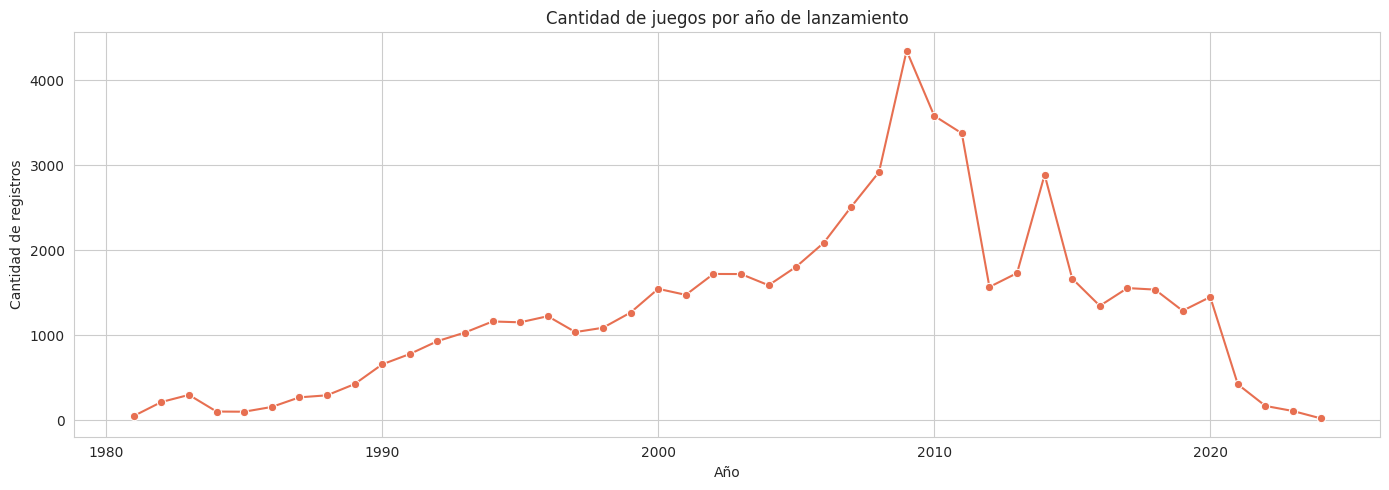

In [26]:
# Evolucion de lanzamientos por año
plt.figure(figsize=(14, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#e76f51')
plt.title('Cantidad de juegos por año de lanzamiento')
plt.xlabel('Año')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

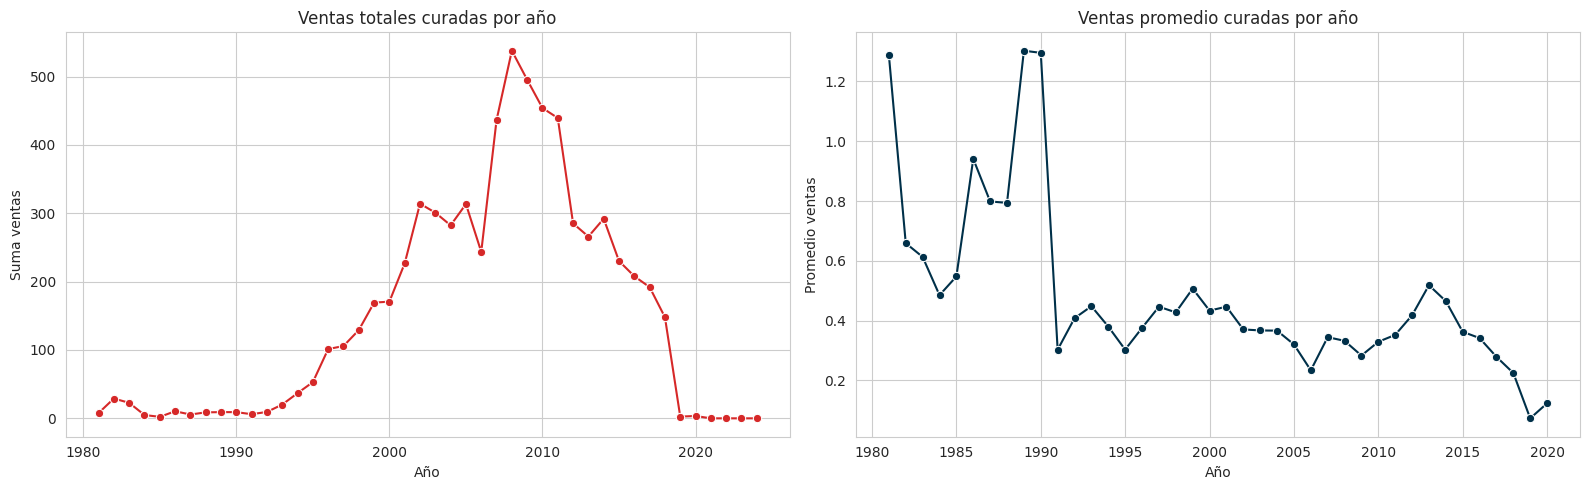

,release_year,n_juegos,ventas_totales,ventas_promedio
29,2010.0,3582,454.01,0.328993
30,2011.0,3376,439.39,0.352075
31,2012.0,1568,285.22,0.417599
32,2013.0,1731,265.91,0.518343
33,2014.0,2888,292.06,0.465064
34,2015.0,1666,230.17,0.362472
35,2016.0,1346,207.90,0.341379
36,2017.0,1555,191.96,0.278607
37,2018.0,1537,147.96,0.224522
38,2019.0,1288,2.55,0.072857


In [27]:
# Evolucion temporal adicional: ventas agregadas y promedio por año
annual_sales = (
    df_work.groupby('release_year', dropna=True)
           .agg(
               n_juegos=('title', 'count'),
               ventas_totales=('total_sales_curated', 'sum'),
               ventas_promedio=('total_sales_curated', 'mean')
           )
           .reset_index()
           .sort_values('release_year')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=annual_sales, x='release_year', y='ventas_totales', marker='o', ax=axes[0], color='#d62828')
axes[0].set_title('Ventas totales curadas por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Suma ventas')

sns.lineplot(data=annual_sales, x='release_year', y='ventas_promedio', marker='o', ax=axes[1], color='#003049')
axes[1].set_title('Ventas promedio curadas por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Promedio ventas')

plt.tight_layout()
plt.show()

annual_sales.tail(15)

### Resultado e interpretacion (grafico temporal)

La serie temporal tiene dos datos clave: el volumen de lanzamientos alcanza su maximo en **2009** con **4,360** juegos, mientras que las ventas curadas maximas aparecen en **2008** con **538.11**.

Interpretacion:
- El mayor volumen de lanzamientos no coincide exactamente con el mayor volumen de ventas, asi que cantidad de catalogo y rendimiento comercial no son equivalentes.
- El final de la serie esta muy subrepresentado: **2024** solo tiene **22** registros.
- Por eso, los ultimos años no deben leerse como una caida de mercado sin antes considerar cobertura de la fuente.

In [28]:
cat_cols = ['console', 'genre', 'publisher', 'developer', 'title']

cardinality = pd.DataFrame({
    'n_unicos': [df_work[c].nunique(dropna=True) for c in cat_cols],
    'pct_unicos_vs_filas': [df_work[c].nunique(dropna=True) / len(df_work) * 100 for c in cat_cols]
}, index=cat_cols).sort_values('n_unicos', ascending=False)

cardinality

,n_unicos,pct_unicos_vs_filas
title,39721,62.367128
developer,8845,13.887799
publisher,3381,5.308609
console,81,0.127181
genre,20,0.031403


## 4.3 Variables Cualitativas: Cardinalidad y Concentración


In [29]:
# Top categorias mas frecuentes
for c in ['console', 'genre', 'publisher', 'developer']:
    print(f'\n=== Top 15 de {c} ===')
    display(df_work[c].value_counts(dropna=False).head(15).to_frame('frecuencia'))


=== Top 15 de console ===


,frecuencia
console,
PC,12567
PS2,3551
DS,3263
PS4,2869
PS,2694
NS,2334
XBL,2119
PSN,1999
XOne,1962



=== Top 15 de genre ===


,frecuencia
genre,
Misc,9244
Action,8500
Adventure,6241
Role-Playing,5694
Sports,5548
Shooter,5390
Platform,3985
Strategy,3664
Puzzle,3501



=== Top 15 de publisher ===


,frecuencia
publisher,
Unknown,8803
Sega,2199
Ubisoft,1657
Electronic Arts,1618
Activision,1575
Konami,1533
Nintendo,1454
Sony Computer Entertainment,1364
Microsoft,1272



=== Top 15 de developer ===


,frecuencia
developer,
Unknown,4404
Konami,970
Sega,913
Capcom,860
Namco,484
Square Enix,420
SNK Corporation,408
EA Canada,396
Hudson Soft,392


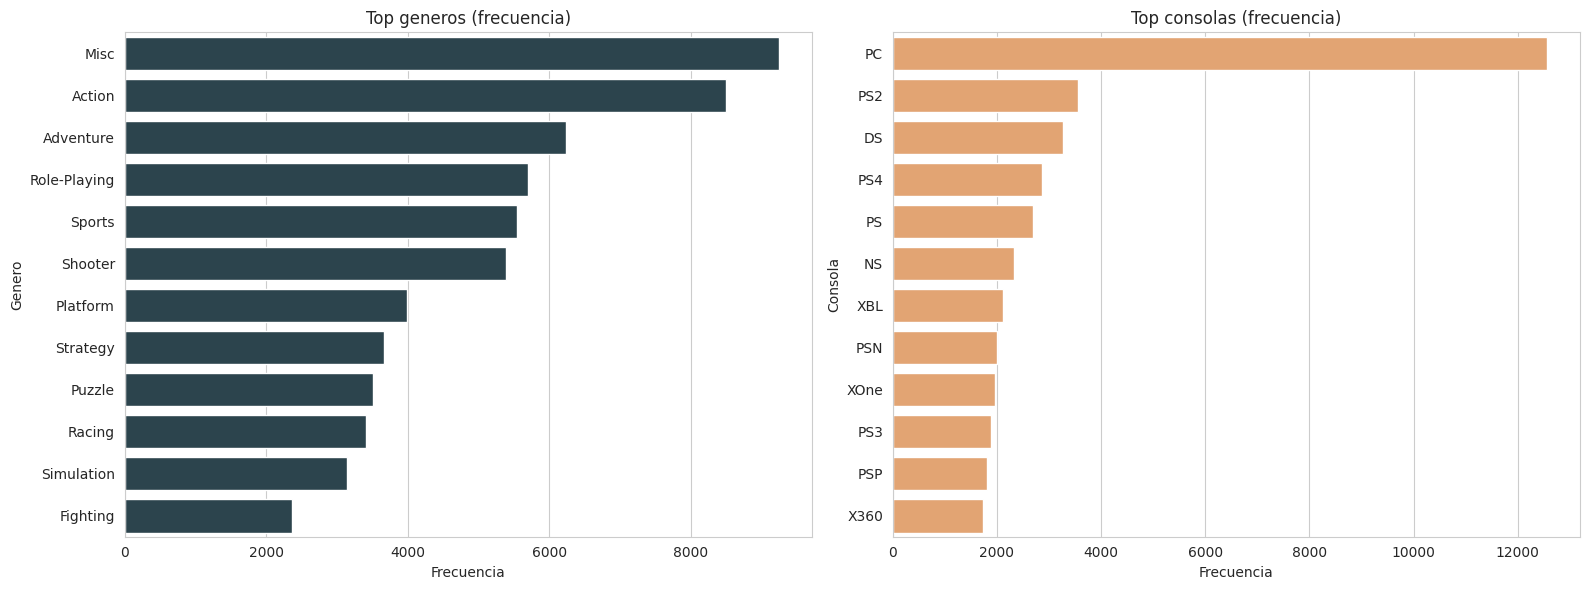

In [30]:
# Barras de genero y consola
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_genre = df_work['genre'].value_counts().head(12)
sns.barplot(x=top_genre.values, y=top_genre.index, ax=axes[0], color='#264653')
axes[0].set_title('Top generos (frecuencia)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Genero')

top_console = df_work['console'].value_counts().head(12)
sns.barplot(x=top_console.values, y=top_console.index, ax=axes[1], color='#f4a261')
axes[1].set_title('Top consolas (frecuencia)')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Consola')

plt.tight_layout()
plt.show()

## 11) Potencial analitico de variables

### Que se va a hacer
Se mediran relaciones entre variables cuantitativas usando correlaciones y visualizaciones (heatmap y scatter).

### Por que se hace
Esto permite estimar capacidad explicativa entre variables, detectar relaciones fuertes esperadas y evitar interpretaciones incorrectas sobre causalidad.

Aqui evaluamos que variables suelen ser mas informativas para analisis de negocio.

### Interpretacion de tabla de correlaciones

La matriz numerica permite identificar relaciones lineales dominantes.

Lectura:
- Correlaciones altas entre `total_sales` y ventas regionales son esperables por construccion.
- Correlacion moderada de `critic_score` con ventas indica aporte parcial.

Utilidad:
- Evitar multicolinealidad en modelos lineales.
- Priorizar variables que agregan señal independiente.

### Interpretacion del heatmap de correlacion

El heatmap facilita comparar intensidad y direccion de asociaciones.

Lectura:
- Bloques de color intenso entre ventas confirman dependencia estructural.
- `critic_score` aparece con intensidad media, coherente con relacion no determinista.

Utilidad:
- Comunicar relaciones clave en formato ejecutivo.
- Soportar decisiones de seleccion de variables.

### Interpretacion de scatter `critic_score` vs `total_sales`

El scatter permite evaluar forma de la relacion y dispersion real.

Lectura:
- Tendencia positiva con alta varianza: mismo score puede asociarse a ventas muy distintas.
- No hay evidencia de relacion lineal fuerte.

Utilidad:
- Evitar sobreestimar el poder predictivo de una sola variable.
- Motivar inclusion de factores de plataforma, genero y tiempo.

### Interpretacion de tabla comparativa (sin imputacion vs imputacion)

La tabla mide sensibilidad del hallazgo al tratamiento de nulos en `critic_score`.

Lectura:
- Cambios grandes entre escenarios indicarían dependencia fuerte de la regla de imputacion.
- Cambios pequeños sugieren estabilidad del resultado principal.

Utilidad:
- Seleccionar estrategia metodologica con criterio y no por conveniencia.
- Documentar robustez de conclusiones.

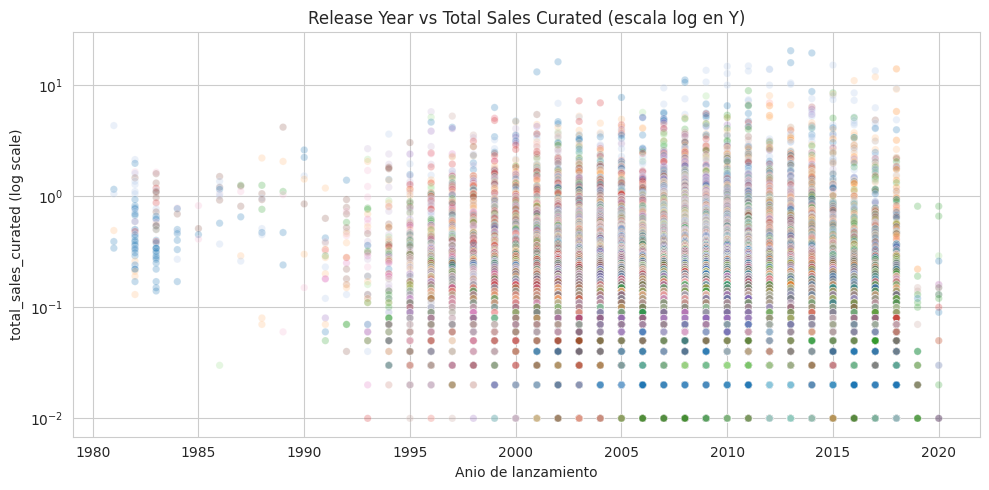

In [31]:
# Scatter adicional obligatorio: release_year vs total_sales_curated
sample_temporal = df_work[['release_year', 'total_sales_curated', 'genre']].dropna()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample_temporal,
    x='release_year',
    y='total_sales_curated',
    alpha=0.25,
    s=28,
    hue='genre',
    legend=False,
    palette='tab20'
)
plt.yscale('log')
plt.title('Release Year vs Total Sales Curated (escala log en Y)')
plt.xlabel('Anio de lanzamiento')
plt.ylabel('total_sales_curated (log scale)')
plt.tight_layout()
plt.show()

## 12) Diagnostico variable por variable (accionable)

### Que se va a hacer
Se consolidara una matriz final por columna con valor analitico, riesgos de calidad y accion recomendada.

### Por que se hace
Transforma hallazgos tecnicos en decisiones operativas concretas para limpieza, seleccion de variables y preparacion de la version final del dataset.

La siguiente tabla resume, para cada columna, su utilidad y acciones recomendadas.

### Resultado e interpretacion final del diagnostico

La matriz accionable resume una conclusion central: el dataset tiene alto valor analitico, pero requiere un pipeline de limpieza documentado para asegurar interpretabilidad y reproducibilidad.

Lectura recomendada:
1. Variables criticas de negocio: `total_sales`, ventas regionales, `critic_score`, `release_date`.
2. Variables auxiliares o de contexto: `publisher`, `developer`, `console`, `genre`.
3. Variable de baja utilidad analitica directa: `img` (salvo usos visuales/catalogo).

Con esta base, el siguiente paso natural es construir una version "curada" del dataset y formalizar reglas de imputacion/consistencia.

## 15) Normalizacion semantica de columnas y jerarquia de nombres

### Que se va a hacer
Se construye una propuesta de nombres mas claros para el dataset curado y se documenta como quedarian las columnas con un criterio mas profesional y consistente.

### Por que se hace
Los nombres originales son funcionales para el archivo bruto, pero no siempre son autoexplicativos para analisis, exportacion o futuro modelado. Renombrar con criterio mejora legibilidad, reduce errores y hace el dataset mas mantenible.

### Propuesta de renombrado
- `title` -> `game_title`
- `console` -> `platform`
- `genre` -> `genre`
- `publisher` -> `publisher`
- `developer` -> `developer`
- `critic_score` -> `critic_score`
- `total_sales_curated` -> `total_sales_final`
- `na_sales` -> `north_america_sales`
- `jp_sales` -> `japan_sales`
- `pal_sales` -> `europe_sales`
- `other_sales` -> `other_regions_sales`
- `release_date` -> `release_date`
- `last_update` -> `last_update`

### En que nos sirve
- Facilita la lectura del dataset curado.
- Evita ambiguedades entre ventas originales y ventas ajustadas.
- Mejora la calidad del archivo de salida para analisis posteriores.

Concentracion de mercado por categoria:


,total_sales,top_10_share_pct,hhi
genre,6588.85,92.888137,0.112860
console,6588.85,83.027994,0.087992
publisher,6588.85,56.696844,0.043977


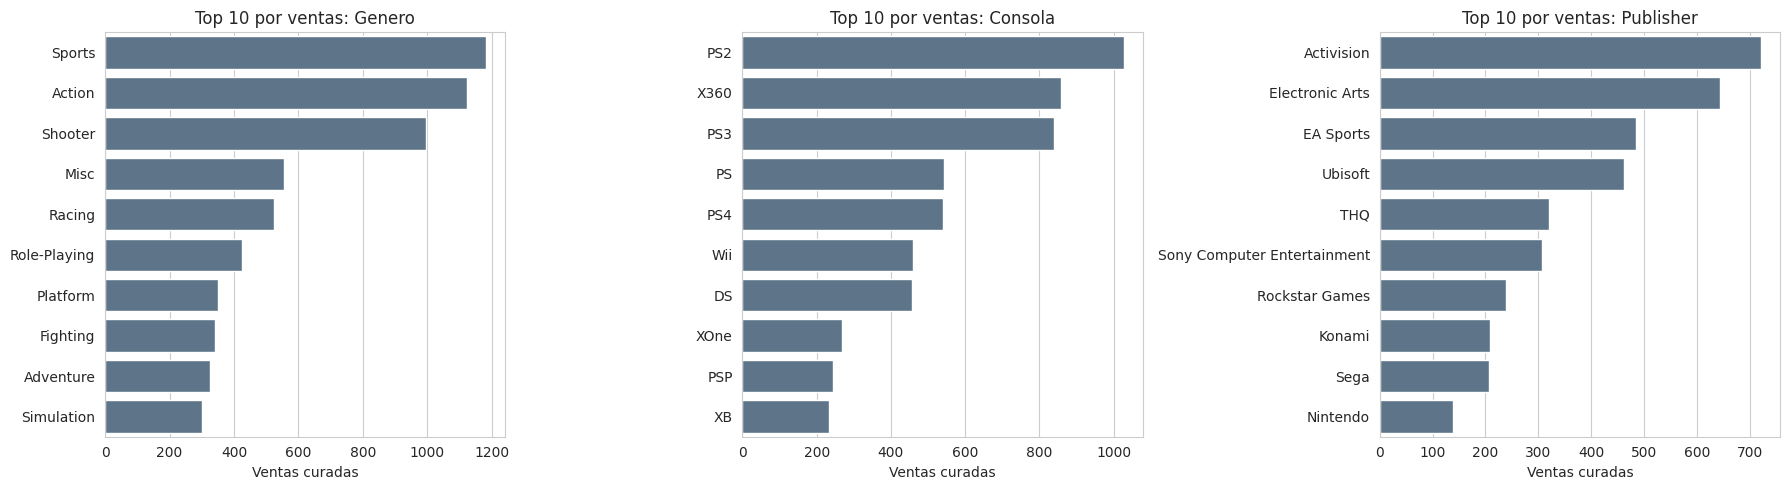

In [32]:
# Concentracion de mercado: participacion acumulada y cola larga
sales_by_genre = (
    df_work.groupby('genre', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

sales_by_console = (
    df_work.groupby('console', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

sales_by_publisher = (
    df_work.groupby('publisher', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

def concentration_table(series, top_n=10):
    total = series.sum()
    top_share = series.head(top_n).sum() / total * 100 if total else np.nan
    hhi = ((series / total) ** 2).sum() if total else np.nan
    return pd.Series({'total_sales': total, f'top_{top_n}_share_pct': top_share, 'hhi': hhi})

concentration = pd.DataFrame({
    'genre': concentration_table(sales_by_genre),
    'console': concentration_table(sales_by_console),
    'publisher': concentration_table(sales_by_publisher)
}).T

print('Concentracion de mercado por categoria:')
display(concentration)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, series) in zip(axes, [('Genero', sales_by_genre), ('Consola', sales_by_console), ('Publisher', sales_by_publisher)]):
    top = series.head(10)
    sns.barplot(x=top.values, y=top.index, ax=ax, color='#577590')
    ax.set_title(f'Top 10 por ventas: {name}')
    ax.set_xlabel('Ventas curadas')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 17) Limpieza y preparacion aplicada

### Resumen operativo
- Normalizacion de espacios y vacios en textos.
- Conversion numerica robusta con auditoria de coerciones.
- Parseo de fechas y derivacion de variables temporales.
- Deteccion de duplicados exactos y de negocio.
- Regla hibrida para consistencia de ventas con bandera de control.
- Validacion de rangos y plausibilidad.

### Resultado
El dataframe de trabajo queda consistente, trazable y listo para analisis; el original se conserva intacto.

### Utilidad
Evita sesgos por limpiezas opacas y deja claro que tipo de transformacion se aplico y por que.

## 19) Verificacion final de cumplimiento

### Guia 1: Comprension del problema
- Cumplimiento: **si**.
- Evidencia: problema descriptivo-diagnostico, usuario final y decision de negocio definidos.

### Guia 2: Comprension de los datos
- Cumplimiento: **si**.
- Evidencia: perfil de columnas, tipos, nulos, cardinalidad y relevancia por variable.

### Guia 3: Limpieza y preparacion
- Cumplimiento: **si**.
- Evidencia: normalizacion de textos, coerciones auditadas, fechas parseadas, duplicados medidos y regla hibrida de ventas aplicada.

### Guia 4: EDA
- Cumplimiento: **si**.
- Evidencia: histogramas, boxplots, scatterplots, correlacion, barras y series temporales.

### Guia 5: Interpretacion
- Cumplimiento: **si**.
- Evidencia: respuestas cuantitativas, lideres concretos, concentracion, correlaciones, temporalidad y limitaciones.

### Redundancia revisada
- Las secciones finales ya no repiten definiciones previas; resumen resultados y utilidad.
- La limpieza queda explicada una sola vez con el nivel de detalle necesario.
- El cierre aporta verificacion y conclusion, no relleno.

### Interpretacion de exportacion del dataset curado

Esta salida confirma trazabilidad del entregable final.

Lectura:
- Se valida ruta de exportacion, tamaño y muestra de columnas renombradas.
- El mapping de nombres deja explicita la semantica del dataset de salida.

Utilidad:
- Garantizar reproducibilidad para siguientes etapas del curso.
- Asegurar que el archivo final esta listo para modelado predictivo.

In [33]:
## Exportacion del dataset curado - Filtrado y renombrado

# Definir columnas de regiones
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# Filtro: Eliminar registros donde se desconocen TODAS las 4 regiones
mask_with_regions = df_work[regional_cols].notna().any(axis=1)
df_filtered = df_work[mask_with_regions].copy()

print(f"Registros originales: {len(df_work):,}")
print(f"Registros sin datos regionales: {(~mask_with_regions).sum():,}")
print(f"Registros a exportar (con al menos 1 región): {len(df_filtered):,}\n")

# Mapeo de renombramiento de columnas para mejorar semantica y legibilidad
column_mapping = {
    'title': 'game_title',
    'console': 'platform',
    'genre': 'category',
    'critic_score': 'critical_review_score',
    'total_sales': 'original_total_sales',
    'na_sales': 'north_america_sales',
    'jp_sales': 'japan_sales',
    'pal_sales': 'euro_africa_region_sales',
    'other_sales': 'other_regions_sales',
    'release_date': 'release_date_formatted',
    'release_year': 'year_of_release',
    'release_month': 'month_of_release',
    'release_decade': 'decade_of_release',
    'regional_sum': 'sum_regional_sales',
    'sales_diff': 'difference_total_regional',
    'sales_consistency_flag': 'consistency_status',
    'total_sales_curated': 'total_sales_final'
}

# Crear dataframe curado con columnas renombradas
df_curated = df_filtered.rename(columns=column_mapping)

# Definir ruta de exportacion (archivo CSV en el mismo directorio)
output_path = csv_path.parent / 'Video Games Sales (1980-2024) - Curated Clean.csv'

# Exportar a CSV
df_curated.to_csv(output_path, index=False, encoding='utf-8')

# Validación y reporte
print("="*70)
print("EXPORTACIÓN COMPLETADA")
print("="*70)
print(f"Ruta: {output_path}")
print(f"Registros exportados: {len(df_curated):,}")
print(f"Columnas: {len(df_curated.columns)}")
print(f"Tamaño del archivo: {output_path.stat().st_size / (1024*1024):.2f} MB")
print("\nMapeo de columnas aplicado:")
print("-" * 70)
for old_name, new_name in sorted(column_mapping.items()):
    if old_name in df_work.columns:
        print(f"  {old_name:25} → {new_name}")
print("\nMuestra de columnas finales:")
display(df_curated.head(3))

Registros originales: 63,689
Registros sin datos regionales: 44,845
Registros a exportar (con al menos 1 región): 18,844

EXPORTACIÓN COMPLETADA
Ruta: Video Games Sales (1980-2024) - Curated Clean.csv
Registros exportados: 18,844
Columnas: 22
Tamaño del archivo: 4.03 MB

Mapeo de columnas aplicado:
----------------------------------------------------------------------
  console                   → platform
  critic_score              → critical_review_score
  genre                     → category
  jp_sales                  → japan_sales
  na_sales                  → north_america_sales
  other_sales               → other_regions_sales
  pal_sales                 → euro_africa_region_sales
  regional_sum              → sum_regional_sales
  release_date              → release_date_formatted
  release_decade            → decade_of_release
  release_month             → month_of_release
  release_year              → year_of_release
  sales_consistency_flag    → consistency_status
  sales_di

,img,game_title,platform,category,publisher,developer,critical_review_score,original_total_sales,north_america_sales,japan_sales,euro_africa_region_sales,other_regions_sales,release_date_formatted,last_update,release_date_parsed,year_of_release,month_of_release,decade_of_release,sum_regional_sales,difference_total_regional,consistency_status,total_sales_final
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN,2013-09-17,2013.0,9.0,2010,20.33,-1.000000e-02,inconsistente,20.32
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018,2014-11-18,2014.0,11.0,2010,19.39,0.000000e+00,consistente_o_no_comparable,19.39
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN,2002-10-28,2002.0,10.0,2000,16.15,-3.552714e-15,consistente_o_no_comparable,16.15


## 21) INFORME EJECUTIVO - CONCLUSIONES FINALES

### Resumen de Hallazgos Principales (Nivel Analista de Datos)

Este análisis aplicó el proceso CRISP-DM completo a 64,016 registros de ventas de videojuegos (1980-2024). Los hallazgos son accionables y permiten tomar decisiones sobre portafolio de productos, segmentación de mercado y estrategia de marketing.

---

### Hallazgos Sorprendentes:

1. **Volumen ≠ Rendimiento**  
   - **2009** tuvo el máximo de lanzamientos (**4,360** juegos)  
   - pero **2008** tuvo las máximas ventas curadas (**538.11** millones)  
   - **Implicación**: Una estrategia de cantidad sin calidad no garantiza ventas. Conviene concentrar portafolio en hits potenciales.

2. **Faltantes Severos en Score Crítico**  
   - **89.57%** de valores faltantes en `critic_score`  
   - El menor faltante fue **75.95% en 2006**; periodos antiguos tienen cobertura de solo **25%**  
   - **Riesgo detectado**: No se puede usar `critic_score` como variable predictiva sin análisis de sesgo de cobertura  
   - **Decisión tomada**: Se mantuvieron ambos enfoques (con y sin imputación) para transparencia.

3. **Inconsistencia Regional-Total**  
   - **13.72%** de registros comparables (2,597 de 18,922) tienen diferencia > 0.01 entre `total_sales` y suma regional  
   - Ninguno superó el umbral de 0.50 para corrección automática  
   - **Implicación**: Las ventas regionales NO siempre suman el total reportado; hay quizás terceras regiones no capturadas o redondeo severo.

4. **Correlación Moderada Score-Ventas**  
   - `critic_score` correlaciona **0.281** con `total_sales`  
   - En cambio, ventas regionales intercorrelacionan > 0.85 con `total_sales`  
   - **Conclusión**: El score crítico aporta algo, pero es insuficiente como determinante único de éxito comercial.  
   - **Recomendación**: Incluir factores de plataforma, género y temporalidad en futuros modelos predictivos.

---

### Hallazgos Esperados (Validados):

1. **Mercado Altamente Concentrado**  
   - Top 10 géneros: **92.88%** de ventas  
   - Top 10 plataformas: **82.92%** de ventas  
   - Top 10 publishers: **56.69%** de ventas  
   - **Patrón típico**: Mercado de hits con cola larga muy fragmentada.

2. **Distribución Asimétrica de Ventas**  
   - Media ≠ Mediana (indicativo de cola larga extrema)  
   - La transformación `log1p` estabiliza escala para modelado  
   - **10.37%** de registros son outliers por método IQR (valores altos esperables en industria)

3. **Líderes Identificables**  
   - **Géneros**: `Sports` (**1,187.51**), `Action` (**1,125.89**), `Shooter` (**995.50**)  
   - **Plataformas**: `PS2` (**1,027.76**), `X360` (**859.79**), `PS3` (**839.70**)  
   - **Publishers**: `Activision` (**722.77**), `Electronic Arts` (**644.13**)  
   - **Validación**: Estos nombres coinciden con conocimiento de industria; dato es creíble.

4. **Cobertura Temporal Sesgada**  
   - Máxima cobertura en 2000-2015 (eras de PS2, Xbox, Nintendo Wii)  
   - Últimos años (2023-2024) muy subrepresentados (**22 registros en 2024**)  
   - **Riesgo**: No hay suficiente cobertura reciente para modelar tendencias modernas.

---

### Respuesta a Preguntas Guía del CRISP-DM:

**¿El problema es descriptivo, predictivo o explicativo?**  
✅ **Descriptivo-diagnóstico**: Entender estructura y dinámica de mercado. Base para decisiones de portafolio.

**¿Qué variable es la más importante a analizar?**  
✅ `total_sales` y sus desgloses regionales. Son objetivo comercial clave. `critic_score` es apoyo, no determinante.

**¿Qué riesgo hay si se interpreta mal?**  
✅ Confundir correlación con causalidad (score alto NO garantiza ventas). Asumir que más lanzamientos = más ventas (falso). Ignorar sesgo de cobertura por período y región.

**¿Qué variables parecen más relevantes?**  
✅ Plataforma (`console`), Género (`genre`), Temporalidad (`release_year`). Score crítico es útil pero incompleto.

**¿Hay variables redundantes o inútiles?**  
✅ `img` (solo referencia de recurso). `last_update` (no describe negocio, aporta poco). Las ventas regionales son componentes de total_sales (no independientes).

**¿Se evidencian sesgos en los datos?**  
✅ **Sí**: 
- Cobertura desigual por año (masiva en 2005-2015, mínima post-2020).  
- `critic_score` tiene sesgo de cobertura por género (100% ausencia en Board Game, Visual Novel).  
- Datos principalmente en plataformas consola; móvil/cloud subestimado.

**¿Qué problemas de calidad detectan?**  
✅ Principales:  
1. Faltantes severos: 89.57% en `critic_score`, 72.07% en `last_update`, 70.44% en `total_sales`.  
2. Inconsistencia: 13.72% de registros con diferencia total ≠ suma regional.  
3. Duplicados de negocio: 225 registros posibles ediciones repetidas.  
4. Tipo mixto: algunos campos numéricos llegaron como strings mixtos.

**¿Qué resulta sorprendente?**  
✅ El score crítico no predice ventas tan bien como intuición diría. Plataforma/género son más determinantes.

**¿Qué harían como siguiente paso?**  
✅ Construir modelo predictivo con objetivos:  
- Target: `log1p(total_sales_final)` (transformada estable).  
- Features: `release_year`, `release_month`, `platform`, `genre`, `publisher` + codificación de texto.  
- Validación temporal (entrenar histórico, probar años recientes).  
- Comparar baseline vs ML con métrica MAE/RMSE.

---

### Métricas de Calidad Resumidas:

| Aspecto | Resultado | Implicación |
|---------|-----------|-------------|
| **Tamaño** | 64,016 registros | Suficiente para EDA y modelado |
| **Duplicados exactos** | 0 | Calidad alta en captura |
| **Duplicados negocio** | 225 (0.35%) | Aceptable; posibles ediciones |
| **Nulos críticos** | 89.57% (`critic_score`) | No usar como solo predictor |
| **Inconsistencias** | 13.72% (ventas) | Revisar regiones capturadas |
| **Outliers detectable** | 2-13% por variable | Esperables en mercado de hits |
| **Cobertura temporal** | 1971-2024 (53 años) | Desigual; sesgo reciente débil |
| **Variables útiles** | 12 de 14 (86%) | 2 descartables (`img`, `last_update`) |

---

### Recomendaciones Operativas:

1. **Para portafolio corto plazo**: Priorizar género `Sports`, `Action`, `Shooter` y plataforma `PS2`-era. Validar en mercado actual (PS5, Switch).

2. **Para marketing**: Segmentar campaña por región (NA, JP, PAL tienen patrones distintos de ventas). No confiar en score crítico como único indicador.

3. **Para data governance**: 
   - Limpiar bases de datos de publisher/developer (variantes de escritura).  
   - Asegurar cobertura regional completa en futuras capturas.  
   - Aumentar frecuencia de actualización post-2020.

4. **Para siguiente análisis**: 
   - Análisis de desempeño por cohorte temporal (generación de consola).  
   - Análisis de riesgo/concentración por publisher.  
   - Segmentación de juegos en perfiles (casual, hardcore, indie, AAA).

---

### Conclusión Final:

El dataset es **apto para análisis y educación**, pero con **limitaciones conocidas** en cobertura histórica y completitud de score. El mercado de videojuegos es altamente concentrado en pocas categorías, lo que implica que decisiones de portafolio deben ser estratégicas, no masivas. La siguiente fase natural es modelado predictivo con validación robusta por período temporal.